<a href="https://colab.research.google.com/github/dzidz1/Freeuni_ML_Walmart_Sales_Forecasting/blob/main/classical_statistical_models/model_experiment_Prophet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Setup & MLflow

In [3]:
!pip install -q mlflow dagshub prophet

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from google.colab import userdata
from prophet import Prophet
from tqdm.auto import tqdm
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

warnings.filterwarnings('ignore')

os.environ['MLFLOW_TRACKING_USERNAME'] = 'adzid23'
os.environ['MLFLOW_TRACKING_PASSWORD'] = userdata.get('DAGSHUB_TOKEN')

mlflow.set_tracking_uri('https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow')
mlflow.set_experiment('Prophet_Training')
print('MLflow connected:', mlflow.get_tracking_uri())

MLflow connected: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow


## 2. Data & Split

In [6]:
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_KEY')
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting -q

os.makedirs('walmart_data', exist_ok=True)
with zipfile.ZipFile('walmart-recruiting-store-sales-forecasting.zip') as z:
    z.extractall('walmart_data')
for f in os.listdir('walmart_data'):
    if f.endswith('.zip'):
        with zipfile.ZipFile(f'walmart_data/{f}') as z:
            z.extractall('walmart_data')

train = pd.read_csv('walmart_data/train.csv', parse_dates=['Date'])
test = pd.read_csv('walmart_data/test.csv', parse_dates=['Date'])
print(train.shape, test.shape)

(421570, 5) (115064, 4)


In [7]:
full_index = pd.date_range(train['Date'].min(), train['Date'].max(), freq='W-FRI')

def make_series(g):
    return g.set_index('Date')['Weekly_Sales'].reindex(full_index).fillna(0.0)

series = {key: make_series(g) for key, g in train.groupby(['Store', 'Dept'])}
print('Series total:', len(series))

Series total: 3331


In [8]:
VAL_WEEKS = 13
val_start = full_index[-VAL_WEEKS]

holiday_map = train.drop_duplicates('Date').set_index('Date')['IsHoliday']
holiday_map = holiday_map.reindex(full_index).fillna(False)
w_val = np.where(holiday_map[val_start:].values, 5.0, 1.0)

def wmae(y_true, y_pred, w):
    return np.sum(w * np.abs(y_true - y_pred)) / np.sum(w)

print('Fit on   :', full_index[0].date(), '→', full_index[-VAL_WEEKS-1].date())
print('Validate :', val_start.date(), '→', full_index[-1].date())
print('Holidays in validation window:', holiday_map[val_start:].sum())

Fit on   : 2010-02-05 → 2012-07-27
Validate : 2012-08-03 → 2012-10-26
Holidays in validation window: 1


In [9]:
lengths = train.groupby(['Store', 'Dept']).size()
mean_sales = train.groupby(['Store', 'Dept'])['Weekly_Sales'].mean()
full_keys = [k for k in series if lengths.get(k, 0) == 143]
full_set = set(full_keys)

top300 = [k for k in mean_sales.sort_values(ascending=False).index if k in full_set][:300]
pool2 = [k for k in full_keys if k not in set(top300)]
rng7 = np.random.default_rng(7)                    # SAME seed as ARIMA/SARIMA → same 600 series
rand300 = [pool2[i] for i in rng7.choice(len(pool2), size=300, replace=False)]
VAL_KEYS = top300 + rand300
print('VAL_KEYS:', len(VAL_KEYS))

VAL_KEYS: 600


In [10]:
def to_prophet_df(key, train_only=True):
    """(Store,Dept) → Prophet long format (ds, y), log1p-transformed.
    train_only=True cuts strictly before val_start."""
    s = series[key]
    if train_only:
        s = s[s.index < val_start]
    return pd.DataFrame({'ds': s.index, 'y': np.log1p(s.values)})

df0 = to_prophet_df(VAL_KEYS[0])
print(df0.shape, '| last train week:', df0.ds.max().date(), '| val_start:', val_start.date())
df0.tail(3)

(130, 2) | last train week: 2012-07-27 | val_start: 2012-08-03


,ds,y
127,2012-07-13,11.828384
128,2012-07-20,11.857319
129,2012-07-27,11.772064


In [11]:
with mlflow.start_run(run_name='Prophet_Data_Preparation'):
    mlflow.set_tags({'stage': 'preprocessing', 'model_family': 'Prophet', 'author': 'adzid23'})
    mlflow.set_tag('mlflow.note.content',
        'Identical construction to ARIMA/SARIMA data prep (same seed 7 → same 600 '
        'validation series) so WMAE is directly comparable across all experiments. '
        'Carried over: log1p transform, 13-week split, 5x holiday WMAE. '
        'New: to_prophet_df converter to (ds, y) long format for Prophet API. '
        'Reference bars: snaive 3611.4, ARIMA log1p 3637.7 (600 series).')
    mlflow.log_params({'n_series': len(series), 'val_weeks': VAL_WEEKS,
                       'transform': 'log1p', 'data_format': 'long (ds, y)',
                       'val_sampling': '300 top + 300 random, seed 7 (same as ARIMA/SARIMA)'})

🏃 View run Prophet_Data_Preparation at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/6/runs/8bb17c7ec0d8432192df6a9d36daf942
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/6


## 3. Baseline - vanilla Prophet

In [12]:
import time

def fit_forecast_prophet(key, horizon=VAL_WEEKS, **prophet_kwargs):
    """Fit Prophet on train portion, return expm1'd forecast for the val window."""
    df = to_prophet_df(key)
    kwargs = dict(yearly_seasonality=True, weekly_seasonality=False,
                  daily_seasonality=False)
    kwargs.update(prophet_kwargs)
    m = Prophet(**kwargs)
    m.fit(df)
    future = pd.DataFrame({'ds': full_index[-horizon:]})
    fc = m.predict(future)['yhat'].values
    return np.expm1(fc)

t0 = time.time()
_ = fit_forecast_prophet(VAL_KEYS[0])
t1 = time.time()
for k in VAL_KEYS[1:5]:
    _ = fit_forecast_prophet(k)
t2 = time.time()
print(f'First fit (incl. Stan warmup): {t1-t0:.1f}s')
print(f'Steady-state: {(t2-t1)/4:.2f}s/series → 600 series ≈ {(t2-t1)/4*600/60:.0f} min')

First fit (incl. Stan warmup): 1.2s
Steady-state: 0.12s/series → 600 series ≈ 1 min


In [13]:
num = den = 0.0
for k in tqdm(VAL_KEYS):
    fc = fit_forecast_prophet(k)
    va = series[k][val_start:].values
    num += np.sum(w_val * np.abs(va - fc)); den += w_val.sum()

baseline_wmae = num / den
print(f'Prophet baseline WMAE: {baseline_wmae:.1f}')
print('Reference: snaive 3611.4 | ARIMA log1p 3637.7 | naive 4628.0 (same 600)')

  0%|          | 0/600 [00:00<?, ?it/s]

Prophet baseline WMAE: 3116.1
Reference: snaive 3611.4 | ARIMA log1p 3637.7 | naive 4628.0 (same 600)


In [14]:
with mlflow.start_run(run_name='Prophet_Baseline'):
    mlflow.set_tags({'stage': 'validation', 'model_family': 'Prophet', 'author': 'adzid23'})
    mlflow.set_tag('mlflow.note.content',
        'Vanilla Prophet: yearly seasonality only (weekly/daily off — data is weekly), '
        'default changepoints, NO holidays yet, log1p. Full 600-series validation — '
        'first architecture fast enough to skip sampling. Yardstick for every '
        'Prophet feature added next: holidays, seasonality mode, changepoint tuning.')
    mlflow.log_params({'yearly_seasonality': True, 'weekly_seasonality': False,
                       'daily_seasonality': False, 'holidays': 'none',
                       'n_series': len(VAL_KEYS), 'transform': 'log1p'})
    mlflow.log_metrics({'val_wmae': baseline_wmae,
                        'val_wmae_snaive': 3611.4, 'val_wmae_arima': 3637.7})

🏃 View run Prophet_Baseline at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/6/runs/1ddaa9e5bad34a11bb9b8037b810bd7e
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/6


## 4. Holiday effects

In [15]:
def make_holidays():
    """Kaggle-ის 4 holiday + explicit pre-Christmas peak. Dates = the Friday
    of the affected week; windows in days (weekly data → 7-day steps)."""
    h = []
    # Super Bowl (early Feb)
    h.append(pd.DataFrame({'holiday': 'super_bowl',
        'ds': pd.to_datetime(['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08']),
        'lower_window': 0, 'upper_window': 0}))
    # Labor Day (early Sep)
    h.append(pd.DataFrame({'holiday': 'labor_day',
        'ds': pd.to_datetime(['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06']),
        'lower_window': 0, 'upper_window': 0}))
    # Thanksgiving — effect spills into the next week (Black Friday aftermath)
    h.append(pd.DataFrame({'holiday': 'thanksgiving',
        'ds': pd.to_datetime(['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29']),
        'lower_window': 0, 'upper_window': 7}))
    # Christmas — THE FIX: peak is the week BEFORE the flagged week.
    # Flagged Fridays: 2010-12-31, 2011-12-30... but sales peak week 51.
    # lower_window=-7 pulls the preceding week into the effect.
    h.append(pd.DataFrame({'holiday': 'christmas',
        'ds': pd.to_datetime(['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27']),
        'lower_window': -7, 'upper_window': 0}))
    return pd.concat(h, ignore_index=True)

holidays_df = make_holidays()
print(holidays_df.groupby('holiday').size())
holidays_df[holidays_df.holiday == 'christmas']

holiday
christmas       4
labor_day       4
super_bowl      4
thanksgiving    4
dtype: int64


,holiday,ds,lower_window,upper_window
12,christmas,2010-12-31,-7,0
13,christmas,2011-12-30,-7,0
14,christmas,2012-12-28,-7,0
15,christmas,2013-12-27,-7,0


In [16]:
num = den = 0.0
for k in tqdm(VAL_KEYS):
    fc = fit_forecast_prophet(k, holidays=holidays_df)
    va = series[k][val_start:].values
    num += np.sum(w_val * np.abs(va - fc)); den += w_val.sum()

holiday_wmae = num / den
print(f'Prophet + holidays WMAE: {holiday_wmae:.1f}  (baseline 3116.1)')

  0%|          | 0/600 [00:00<?, ?it/s]

Prophet + holidays WMAE: 2828.9  (baseline 3116.1)


In [17]:
with mlflow.start_run(run_name='Prophet_Holiday_Effects'):
    mlflow.set_tags({'stage': 'validation', 'model_family': 'Prophet', 'author': 'adzid23'})
    mlflow.set_tag('mlflow.note.content',
        'Custom holiday calendar built from dates, NOT the IsHoliday flag — fixes the '
        'EDA-diagnosed misalignment: Christmas sales peak in week 51 (unflagged), so '
        'christmas gets lower_window=-7. Thanksgiving gets upper_window=7 (post-Black-'
        'Friday spillover). Each (holiday, offset) = independent dummy regressor. '
        'Full 600 series.')
    mlflow.log_params({'holidays': 'super_bowl, labor_day, thanksgiving(+7), christmas(-7)',
                       'christmas_fix': 'lower_window=-7 captures week-51 peak',
                       'n_series': len(VAL_KEYS)})
    mlflow.log_metrics({'val_wmae': holiday_wmae, 'val_wmae_baseline': 3116.1})

🏃 View run Prophet_Holiday_Effects at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/6/runs/ae559015b47043c0b5cf2edb63d54978
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/6


## 5. Seasonality mode - additive vs multiplicative

In [18]:
num_m = den_m = 0.0
for k in tqdm(VAL_KEYS):
    fc = fit_forecast_prophet(k, holidays=holidays_df, seasonality_mode='multiplicative')
    va = series[k][val_start:].values
    num_m += np.sum(w_val * np.abs(va - fc)); den_m += w_val.sum()

mult_wmae = num_m / den_m
print(f'multiplicative (log space): {mult_wmae:.1f}  |  additive (log space): 2828.9')

  0%|          | 0/600 [00:00<?, ?it/s]

multiplicative (log space): 2823.9  |  additive (log space): 2828.9


In [19]:
with mlflow.start_run(run_name='Prophet_Seasonality_Mode'):
    mlflow.set_tags({'stage': 'validation', 'model_family': 'Prophet', 'author': 'adzid23'})
    mlflow.set_tag('mlflow.note.content',
        'Additive vs multiplicative seasonality, both on log1p data. Subtlety: '
        'additive-in-log-space is already multiplicative-in-raw-space, so '
        'multiplicative-in-log-space is a double level-dependence — expected to lose. '
        'Test run for completeness/report; holidays included in both.')
    mlflow.log_params({'compared': 'additive vs multiplicative (log space)',
                       'holidays': 'custom calendar', 'n_series': len(VAL_KEYS)})
    mlflow.log_metrics({'val_wmae_multiplicative': mult_wmae,
                        'val_wmae_additive': 2828.9})

🏃 View run Prophet_Seasonality_Mode at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/6/runs/a5904eb8b540426cab48103c833360dd
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/6


## 6. Changepoint tuning

In [20]:
cps_grid = [0.01, 0.05, 0.1, 0.5]
cps_results = {}

for cps in cps_grid:
    num = den = 0.0
    for k in tqdm(VAL_KEYS, desc=f'cps={cps}'):
        fc = fit_forecast_prophet(k, holidays=holidays_df,
                                  changepoint_prior_scale=cps)
        va = series[k][val_start:].values
        num += np.sum(w_val * np.abs(va - fc)); den += w_val.sum()
    cps_results[cps] = num / den
    print(f'cps={cps}: WMAE {cps_results[cps]:.1f}')

best_cps = min(cps_results, key=cps_results.get)
print(f'\nBest: cps={best_cps} → {cps_results[best_cps]:.1f}')

cps=0.01:   0%|          | 0/600 [00:00<?, ?it/s]

cps=0.01: WMAE 2755.1


cps=0.05:   0%|          | 0/600 [00:00<?, ?it/s]

cps=0.05: WMAE 2828.9


cps=0.1:   0%|          | 0/600 [00:00<?, ?it/s]

cps=0.1: WMAE 2890.0


cps=0.5:   0%|          | 0/600 [00:00<?, ?it/s]

cps=0.5: WMAE 3444.7

Best: cps=0.01 → 2755.1


In [21]:
with mlflow.start_run(run_name='Prophet_Changepoint_Tuning'):
    mlflow.set_tags({'stage': 'tuning', 'model_family': 'Prophet', 'author': 'adzid23'})
    mlflow.set_tag('mlflow.note.content',
        'changepoint_prior_scale grid on full 600 series, holidays + additive fixed. '
        'Forecast-specific risk of high cps: last-changepoint slope extrapolates '
        'linearly over all 13 val weeks — flexibility that helps in-sample can '
        'wreck the horizon. Expected U-shape around the default.')
    mlflow.log_params({'grid': str(cps_grid), 'best_cps': best_cps,
                       'holidays': 'custom', 'seasonality_mode': 'additive',
                       'n_series': len(VAL_KEYS)})
    for cps, v in cps_results.items():
        mlflow.log_metric(f'val_wmae_cps_{str(cps).replace(".", "_")}', v)
    mlflow.log_metric('val_wmae_best', cps_results[best_cps])

🏃 View run Prophet_Changepoint_Tuning at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/6/runs/39fa6c370a754e19aa9333917d4e720b
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/6


In [22]:
for cps in [0.001, 0.005]:
    num = den = 0.0
    for k in tqdm(VAL_KEYS, desc=f'cps={cps}'):
        fc = fit_forecast_prophet(k, holidays=holidays_df,
                                  changepoint_prior_scale=cps)
        va = series[k][val_start:].values
        num += np.sum(w_val * np.abs(va - fc)); den += w_val.sum()
    cps_results[cps] = num / den
    print(f'cps={cps}: WMAE {cps_results[cps]:.1f}')

best_cps = min(cps_results, key=cps_results.get)
print(f'\nFinal grid: { {k: round(v,1) for k,v in sorted(cps_results.items())} }')
print(f'Best: cps={best_cps} → {cps_results[best_cps]:.1f}')

cps=0.001:   0%|          | 0/600 [00:00<?, ?it/s]

ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmds

cps=0.001: WMAE 3264.8


cps=0.005:   0%|          | 0/600 [00:00<?, ?it/s]

ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted


cps=0.005: WMAE 2833.8

Final grid: {0.001: np.float64(3264.8), 0.005: np.float64(2833.8), 0.01: np.float64(2755.1), 0.05: np.float64(2828.9), 0.1: np.float64(2890.0), 0.5: np.float64(3444.7)}
Best: cps=0.01 → 2755.1


In [23]:
with mlflow.start_run(run_name='Prophet_Changepoint_Tuning_Extended'):
    mlflow.set_tags({'stage': 'tuning', 'model_family': 'Prophet', 'author': 'adzid23'})
    mlflow.set_tag('mlflow.note.content',
        'Grid-edge check after 0.01 won the initial grid. Extended stiffer: '
        '0.001→3264.8, 0.005→2833.8 — U-shape confirmed, cps=0.01 is a genuine '
        'interior optimum (2755.1). Note: at cps=0.001 LBFGS frequently terminated '
        'abnormally (Newton fallback) — near-rigid trend prior makes the posterior '
        'badly conditioned; fits still valid but numerically fragile. Full 600 series.')
    mlflow.log_params({'extended_grid': '[0.001, 0.005]', 'best_cps': 0.01,
                       'lbfgs_instability': 'frequent at cps=0.001'})
    for cps, v in sorted(cps_results.items()):
        mlflow.log_metric(f'val_wmae_cps_{str(cps).replace(".", "_")}', v)
    mlflow.log_metric('val_wmae_best', cps_results[0.01])

🏃 View run Prophet_Changepoint_Tuning_Extended at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/6/runs/d04cf246a1bf49be91677d06bc176cee
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/6


## 7. Visual check

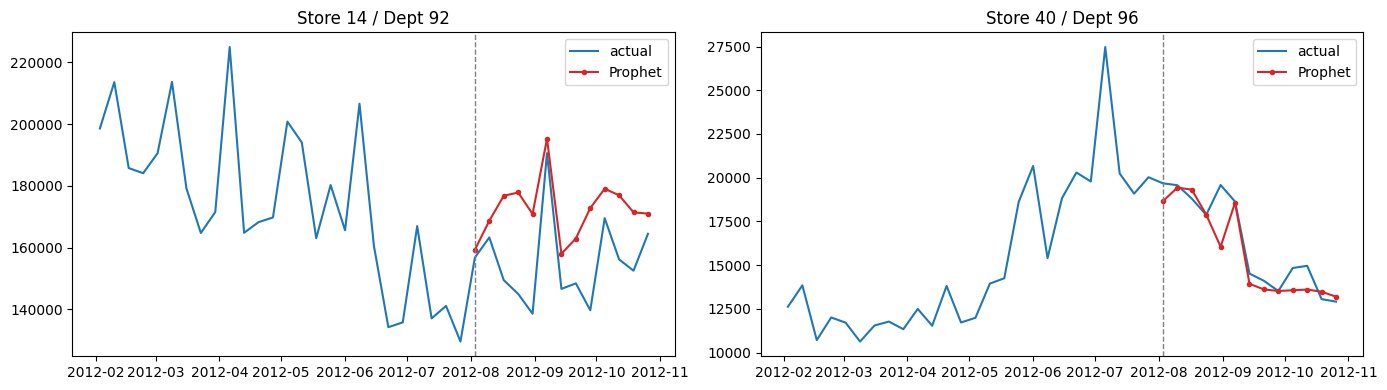

In [24]:
BEST = dict(holidays=holidays_df, changepoint_prior_scale=0.01)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, k in zip(axes, [VAL_KEYS[0], VAL_KEYS[400]]):   # one top, one random
    fc = fit_forecast_prophet(k, **BEST)
    s = series[k]
    ax.plot(s.index[-39:], s.values[-39:], label='actual', color='tab:blue')
    ax.plot(s.index[-13:], fc, label='Prophet', color='tab:red', marker='o', ms=3)
    ax.axvline(val_start, ls='--', c='gray', lw=1)
    ax.set_title(f'Store {k[0]} / Dept {k[1]}')
    ax.legend()
plt.tight_layout(); plt.show()

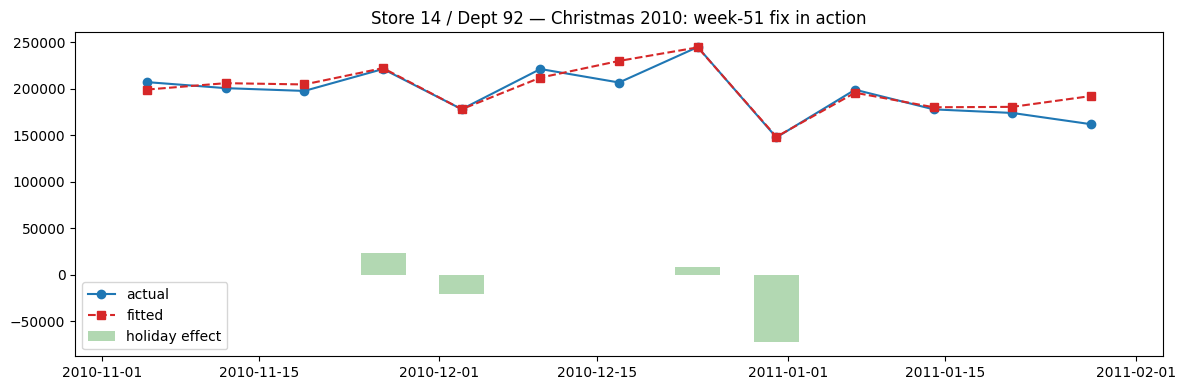

In [25]:
k = VAL_KEYS[0]
df_full = pd.DataFrame({'ds': series[k].index, 'y': np.log1p(series[k].values)})
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
            holidays=holidays_df, changepoint_prior_scale=0.01)
m.fit(df_full)
fitted = m.predict(df_full[['ds']])

fig, ax = plt.subplots(figsize=(12, 4))
mask = (df_full.ds >= '2010-11-01') & (df_full.ds <= '2011-01-31')
ax.plot(df_full.ds[mask], np.expm1(df_full.y[mask]), 'o-', label='actual', color='tab:blue')
ax.plot(fitted.ds[mask], np.expm1(fitted.yhat[mask]), 's--', label='fitted', color='tab:red')
hol = np.expm1(fitted.yhat[mask]) - np.expm1((fitted.yhat - fitted.holidays)[mask])
ax.bar(fitted.ds[mask], hol, width=4, alpha=0.3, color='green', label='holiday effect')
ax.set_title(f'Store {k[0]} / Dept {k[1]} — Christmas 2010: week-51 fix in action')
ax.legend(); plt.tight_layout(); plt.show()

## 8. Final Pipeline - pyfunc

In [32]:
import mlflow.pyfunc

class ProphetPipeline(mlflow.pyfunc.PythonModel):
    """Raw test.csv (Store, Dept, Date[, IsHoliday]) in → Weekly_Sales predictions out."""

    MIN_OBS = 20

    def load_context(self, context):
        import pandas as pd, numpy as np
        train = pd.read_csv(context.artifacts['train_csv'], parse_dates=['Date'])
        self.full_index = pd.date_range(train['Date'].min(), train['Date'].max(),
                                        freq='W-FRI')
        self.series = {k: g.set_index('Date')['Weekly_Sales']
                          .reindex(self.full_index).fillna(0.0)
                       for k, g in train.groupby(['Store', 'Dept'])}
        self.n_obs = train.groupby(['Store', 'Dept']).size().to_dict()
        self.dept_mean = train.groupby('Dept')['Weekly_Sales'].mean().to_dict()
        self.global_mean = train['Weekly_Sales'].mean()
        self.holidays_df = self._make_holidays()
        self._cache = {}

    @staticmethod
    def _make_holidays():
        import pandas as pd
        h = []
        h.append(pd.DataFrame({'holiday': 'super_bowl',
            'ds': pd.to_datetime(['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08']),
            'lower_window': 0, 'upper_window': 0}))
        h.append(pd.DataFrame({'holiday': 'labor_day',
            'ds': pd.to_datetime(['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06']),
            'lower_window': 0, 'upper_window': 0}))
        h.append(pd.DataFrame({'holiday': 'thanksgiving',
            'ds': pd.to_datetime(['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29']),
            'lower_window': 0, 'upper_window': 7}))
        h.append(pd.DataFrame({'holiday': 'christmas',
            'ds': pd.to_datetime(['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27']),
            'lower_window': -7, 'upper_window': 0}))
        return pd.concat(h, ignore_index=True)

    def _forecast_key(self, key, dates):
        import pandas as pd, numpy as np
        from prophet import Prophet
        if key not in self._cache:
            if key not in self.series:                       # unseen (Store, Dept)
                val = self.dept_mean.get(key[1], self.global_mean)
                self._cache[key] = ('dept_mean', val)
            elif self.n_obs.get(key, 0) < self.MIN_OBS:      # too short
                self._cache[key] = ('naive', float(self.series[key].iloc[-1]))
            else:
                df = pd.DataFrame({'ds': self.series[key].index,
                                   'y': np.log1p(self.series[key].values)})
                m = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                            daily_seasonality=False, holidays=self.holidays_df,
                            changepoint_prior_scale=0.01)
                m.fit(df)
                self._cache[key] = ('prophet', m)
        kind, obj = self._cache[key]
        if kind == 'prophet':
            fc = obj.predict(pd.DataFrame({'ds': dates}))['yhat'].values
            return np.clip(np.expm1(fc), 0, None)
        return np.full(len(dates), obj)

    def predict(self, context, model_input):
        import pandas as pd, numpy as np
        df = model_input.copy()
        df = df.reset_index(drop=True)
        df['Date'] = pd.to_datetime(df['Date'])
        out = np.empty(len(df))
        for key, g in df.groupby(['Store', 'Dept']):
            out[g.index.values] = self._forecast_key(
                key, pd.DatetimeIndex(sorted(g['Date'].unique()))
            )[pd.DatetimeIndex(sorted(g['Date'].unique())).get_indexer(g['Date'])]
        df['pred'] = out
        return df['pred'].values

/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [33]:
from mlflow.models.signature import ModelSignature
from mlflow.types.schema import Schema, ColSpec

signature = ModelSignature(
    inputs=Schema([ColSpec('long', 'Store'), ColSpec('long', 'Dept'),
                   ColSpec('string', 'Date')]),
    outputs=Schema([ColSpec('double')])
)

with mlflow.start_run(run_name='Prophet_Final_Pipeline'):
    mlflow.set_tags({'stage': 'pipeline', 'model_family': 'Prophet', 'author': 'adzid23'})
    mlflow.set_tag('mlflow.note.content',
        'Final pyfunc: raw test.csv in → Weekly_Sales out, all preprocessing inside. '
        'Config: custom holidays (week-51 Christmas fix, Thanksgiving +7d spillover), '
        'additive seasonality, cps=0.01, log1p. Fallback: <20 obs → naive, unseen '
        '(Store,Dept) → dept mean. Per-key model cache; ~0.12s/series → full test.csv '
        'feasible inside predict(). Val WMAE 2755.1 (600 series) vs snaive 3611.4 '
        '(−23.7%), SARIMA 3291.7 (200-series subset), ARIMA 3637.7. Best model so far.')
    mlflow.log_params({'changepoint_prior_scale': 0.01, 'seasonality_mode': 'additive',
                       'holidays': 'custom calendar w/ week-51 fix', 'transform': 'log1p',
                       'min_obs': 20, 'fallback': 'naive → dept_mean'})
    mlflow.log_metric('val_wmae', 2755.1)

    model_info = mlflow.pyfunc.log_model(
        artifact_path='prophet_pipeline',
        python_model=ProphetPipeline(),
        artifacts={'train_csv': 'walmart_data/train.csv'},
        signature=signature,
        pip_requirements=['prophet', 'pandas', 'numpy']
    )
    run_id = mlflow.active_run().info.run_id
print('run_id:', run_id)
print('model_uri:', model_info.model_uri)

2026/07/12 00:10:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/12 00:10:16 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


🏃 View run Prophet_Final_Pipeline at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/6/runs/7825a0a4fdc34a5484710e824846553e
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/6
run_id: 7825a0a4fdc34a5484710e824846553e
model_uri: models:/m-410439df5bc541d787ae27789c772d95


In [34]:
loaded = mlflow.pyfunc.load_model(model_info.model_uri)

smoke = test[test[['Store', 'Dept']].apply(tuple, axis=1)
             .isin([(1, 1), (14, 92)])][['Store', 'Dept', 'Date']].copy()
smoke['Date'] = smoke['Date'].astype(str)

preds = loaded.predict(smoke)
smoke['pred'] = preds
print(smoke.groupby(['Store', 'Dept'])['pred'].describe()[['count', 'mean', 'min', 'max']])

            count           mean            min            max
Store Dept                                                    
1     1      39.0   23469.564866   15492.782452   53333.653391
14    92     39.0  145371.034979  118056.549321  197354.749148
